# Кластеризация

Задачи *обучения без учителя*:

- **Понижение размерности** (упрощение модели, визуализация, сжатие информации, получение новых признаков)

- **Кластеризация** (сегментирование данных для упрощения обработки, выделение нетипичных объектов)


В роли обучающей выборки выступает набор объектов $x_{1},...,x_{n}$, он же выступает в роли тестовой выборки. Задача состоит в проставлении меток $y_{1},...,y_{n}$ так, что бы объекты с одной и той же меткой были похожи, а с разными - нет. То есть все объекты в пространстве признаков нужно разделить на кластеры $C_{1}, C_{2}, ..., C_{k}$, изучая структуру данных. Это и называется _кластеризацией_.

Примерами кластеризации может быть группирование новостей по темам, музыки по жанрам, клиентов по типу поведения и т.д.

<div>
<img src="https://drive.google.com/uc?export=view&id=12V-qLNK4k146Qm6QIryf6C0NracgsRDK" width="600"/>
</div>

## Метрики кластеризации

Примеры метрик:

- **Внутрикластерное расстояние** (компактность кластеров, _cluster cohesion_): $$\sum_{i=1}^{k}\sum_{x \in C_{i}}d(x, \mu_{i}),$$ где $k$ - количество кластеров, $\mu_{i}$ - центр i-го кластера (_центроид_): $$\mu_i=\frac{1}{|C_i|}\sum_{x \in C_i}x,$$ где $|C_{i}|$ - количество элементов в кластере под номером $i$. Этот функционал нужно минимизировать, так как в идеальном случае все объекты в одном кластере одинаковы, и расстояние между ними равно нулю.


- **Межкластерное расстояние** (отделимость кластеров, _cluster separation_):
для любых $x_i\in C_{i}$ и $x_j \in C_{j}$
$$\sum_{1\leq i < j \leq k}d(x_i, x_j).$$ Этот функционал наоборот нужно максимизировать, так как объекты из разных кластеров должны максимально различаться, то есть иметь максимальное расстояние между собой.

- Часто используются те же формулы, но включающие не расстояние, а его квадрат, получая **квадратичное внутрикластерное и межкластерное расстояние**:

    $$\sum_{i=1}^{k}\sum_{x \in C_{i}}d^{2}(x, \mu_{i}),$$
    $$\sum_{1\leq i < j \leq k}d^{2}(x_{i}, x_{j}).$$


- **Среднее внутрикластерное расстояние** (среднее расстояние внутри каждого кластера, просуммированное по всем кластерам) и **среднее межкластерное расстояние** (минимизируется и максимизируется, соответственно, по аналогии с двумя первыми функционалами):

    $$\sum_{i=1}^{k}\frac{1}{|C_{i}|}\sum_{x \in C_{i}}d(x, \mu_{i}),$$
    $$\frac{1}{k}\sum_{1\leq i < j \leq k}d(x_{i}, x_{j}).$$

- По аналогии с квадратичным внутрикластерным и межкластерным расстоянием - **среднее квадратичное внутрикластерное и межкластерное расстояние**.

    $$\sum_{i=1}^{k}\frac{1}{|C_{i}|}\sum_{x \in C_{i}}d^{2}(x, \mu_{i}),$$
    $$\frac{1}{k}\sum_{1\leq i < j \leq k}d^{2}(x_{i}, x_{j}).$$

- **Отношение внутрикластерного и межкластерного расстояний** (или средних), минимизируется.


- **Индекс Данна** (Dunn Index): $$\frac{\text{min}_{1\leq i < j \leq k}\, d(\mu_{i},\mu_{j})}{\text{max}_{1\leq i \leq k}\, d_{i}},$$ где $d(\mu_{i},\mu_{j})$ - расстояние между кластерами $i$ и $j$ (между их центрами), $d_{i}$ - внутрикластерное расстояние для кластера $i$. Этот функционал требуется максимизировать.

## Алгоритм k-Means

Одним из самых простых и популярных алгоритмов кластеризации является алгоритм _k-Means (k средних)_.

1. Задаем число кластеров.
2. Центры кластеров (центроиды) случайно инициализируются.
3. От каждой точки рассчитываем расстояние до центра каждого кластера.
4. Присваиваем каждую точку к тому кластеру, к центру которого она ближе.
5. Пересчитываем центры кластеров: для точек каждого кластера считаем среднее по всем признакам и переносим в эту точку центр кластера.
6. Итеративно повторяем шаги 3-5, пока центры кластеров не перестанут "двигаться" (значительно перемещаться).

<div>
<img src="https://drive.google.com/uc?export=view&id=1038l-p6pj7fumBaTCbUSp4RK1SIi9oId" width="500"/>
</div>

Проблемой метода является необходимость знать число кластеров, на которые будет делиться выборка. В случае, когда это число неизвестно, вариантом ее решения может быть последовательная кластеризация на разное число кластеров (например, от 1 до 10) с последующим анализом качества работы алгоритма, например, по сумме квадратов внутрикластерных расстояний $$\sum_{i=1}^{k}\sum_{x \in C_{i}}d(x, \mu_{i})^{2}$$ выбирается такое число кластеров, начиная с которого при увеличении количества кластеров функционал падает незначительно.

### Реализация k-Means

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import seaborn as sns

In [ ]:
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.cluster import KMeans

In [ ]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.5)
plt.rcParams['figure.figsize'] = [4, 3]

Сгенерируем три облака точек.

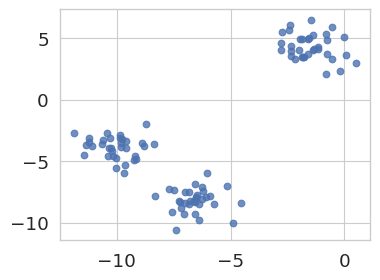

In [ ]:
X, y = make_blobs(n_samples=100,
                  n_features=2,
                  centers=3,
                  cluster_std=1.0,
                  random_state=1)

plt.scatter(X[:, 0], X[:, 1], alpha=0.8);

В качестве метрики расстояния будем использовать евклидово расстояние (функция `np.linalg.norm`). В качестве центроидов выберем первые $k$ элементов датасета. Реализуем основной цикл алгоритма.

In [ ]:
def kmeans(data, k, max_iterations, min_distance):

    # инициализируем центроиды как первые k элементов датасета
    centroids = [data[i] for i in range(k)]

    for i in range(max_iterations):
        # Создадим словарь для классификации
        clusters = {i: [] for i in range(k)}
        # классифицируем объекты по центроидам
        for x in data:
            # определим расстояния от объекта до каждого центроида
            distances = [np.linalg.norm(x - centroid) for centroid in centroids]
            # отнесем объект к кластеру, до центроида которого наименьшее расстояние
            num_cluster = distances.index(min(distances))
            clusters[num_cluster].append(x)

        # сохраним предыдущие центроиды в отдельный список для последующего сравнения сновыми
        old_centroids = centroids.copy()

        # пересчитаем центроиды как среднее по кластерам
        for num_cluster in clusters:
            centroids[num_cluster] = np.mean(clusters[num_cluster], axis=0)

        break_flag = True
        # сравним величину смещения центроидов с минимальной
        for ind in range(len(centroids)):
            distance = np.linalg.norm(centroids[ind] - old_centroids[ind])
            if distance > min_distance:
                break_flag = False

        # если все смещения меньше минимального, останавливаем алгоритм
        if break_flag:
            break

    print('Stop iteration:', i)
    return np.array(old_centroids), clusters

In [ ]:
def kmeans_vis(centroids, clusters):
    colors = ['r', 'g', 'b']

    # нанесем объекты, раскрашенные по классам
    for num_cluster in clusters:
      C = np.array(clusters[num_cluster])
      plt.scatter(C[:, 0], C[:, 1], c=colors[num_cluster], alpha=0.8)

    # нанесем на график центроиды
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=130, c='black')

In [ ]:
# зададим минимальное расстояние между центроидами, при котором нужно остановить алгоритм
min_distance = 1e-4

# определим известное нам количество кластеров
k = 3

Проверим работу алгоритма пошагово.

Stop iteration: 0


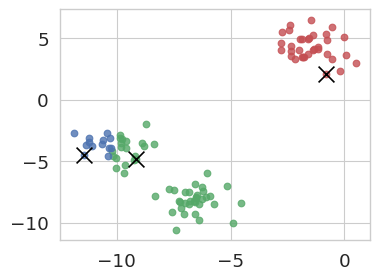

In [ ]:
max_iterations = 1

centroids, clusters = kmeans(X, k, max_iterations, min_distance)

kmeans_vis(centroids, clusters)

Stop iteration: 1


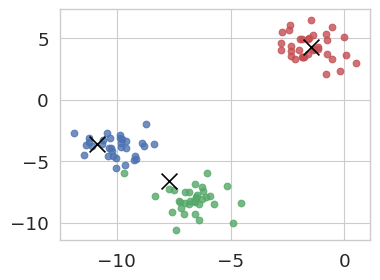

In [ ]:
max_iterations = 2

centroids, clusters = kmeans(X, k, max_iterations, min_distance)

kmeans_vis(centroids, clusters)

Stop iteration: 2


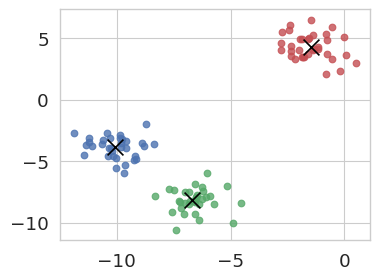

In [ ]:
max_iterations = 3

centroids, clusters = kmeans(X, k, max_iterations, min_distance)

kmeans_vis(centroids, clusters)

Stop iteration: 3


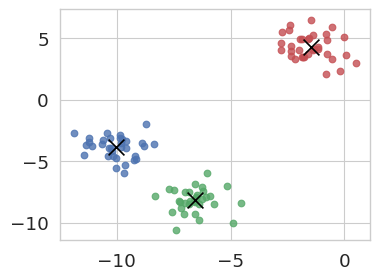

In [ ]:
max_iterations = 10

centroids, clusters = kmeans(X, k, max_iterations, min_distance)

kmeans_vis(centroids, clusters)

In [ ]:
centroids

array([[ -1.4710815 ,   4.33721882],
       [ -6.58196786,  -8.17239339],
       [-10.04935243,  -3.85954095]])

Метод k-Means очень чувствителен к выбору начальных центров кластеров, это является одним из его основных минусов, среди которых также сложность работы с разными формами кластеров.

### Модель KMeans из библиотеки scikit-learn

In [ ]:
from sklearn.cluster import KMeans

KMeans().get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 8,
 'n_init': 'warn',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

### Параметры KMeans

- `n_clusters`, default=8 - количество кластеров
- `init`: {'k-means++', 'random'}, default=’k-means++’ - метод инициализации центроидов
- `max_iter`, default=300 - максимальное число итераций
- `algorithm`, {“lloyd”, “elkan”, “auto”, “full”}, default=”lloyd” - используемый алгоритм

In [ ]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(X)

KMeans(n_clusters=3, random_state=42)

In [ ]:
model.labels_

array([1, 2, 2, 2, 0, 0, 0, 2, 1, 1, 2, 2, 0, 1, 0, 0, 0, 1, 2, 2, 0, 2,
       0, 1, 2, 0, 0, 1, 1, 0, 1, 1, 0, 1, 2, 0, 2, 2, 2, 0, 0, 2, 1, 2,
       2, 0, 1, 1, 1, 1, 2, 0, 0, 0, 1, 0, 2, 2, 1, 1, 2, 0, 0, 2, 2, 0,
       1, 0, 1, 2, 2, 2, 0, 1, 1, 2, 0, 0, 1, 2, 1, 2, 2, 0, 1, 1, 1, 1,
       2, 1, 0, 1, 1, 2, 2, 0, 0, 1, 0, 1], dtype=int32)

In [ ]:
centroids_ = model.cluster_centers_
centroids_

array([[ -6.58196786,  -8.17239339],
       [ -1.4710815 ,   4.33721882],
       [-10.04935243,  -3.85954095]])

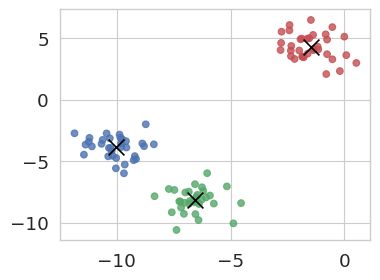

In [ ]:
cmap = LinearSegmentedColormap.from_list('', ['g', 'r', 'b'])

# нанесем объекты, раскрашенные по классам
plt.scatter(X[:, 0], X[:, 1], c=model.labels_, alpha=0.8, cmap=cmap)

# нанесем на график центроиды
plt.scatter(centroids_[:, 0], centroids_[:, 1], marker='x', s=130, c='black');

Алгоритм k-Means минимизирует критерий *inertia* (инерцию), он же критерий суммы квадратов внутри кластера:

$$\sum_{i=1}^{n}\min_{\mu_{j} \in C_{j}}d(x_i, \mu_{j})^{2}$$



In [ ]:
model.inertia_

156.28289251170003

## Дополнительный материал

[KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

[Comparison of the clustering algorithms in scikit-learn](https://scikit-learn.org/stable/modules/clustering.html)

[Обзор методов кластеризации](https://scikit-learn.ru/clustering/)

## Задания

1. Написать функцию подсчета метрики качества кластеризации как среднее квадратичное внутриклассовое расстояние и построить график ее зависимости от количества кластеров $k$ (взять от 1 до 10) для выборки данных из  урока (6 баллов).


<div>
<img src="https://drive.google.com/uc?export=view&id=16o1N0GZmTJFLYhR8l3zXNEMm9xdeQNAj" width="400"/>
</div>



2. Визульно сравните работу функции kmeans и KMeans из библиотеки scikit-learn  на трех наборах сгенерированных данных (6 баллов).

In [ ]:
from sklearn.datasets import make_circles, make_moons, make_blobs

# noisy circles
X1, y1 = make_circles(n_samples=1000, factor=0.5, noise=0.05, random_state=42)
# noisy moons
X2, y2 = make_moons(n_samples=1000, noise=0.05, random_state=42)
# noisy blobs
X3, y3 = make_blobs(n_samples=1000,
                    centers=3,
                    cluster_std=[1.0, 5.0, 2.5],
                    random_state=42)

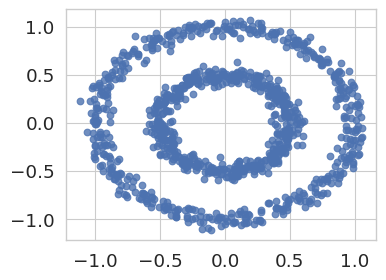

In [ ]:
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.8);

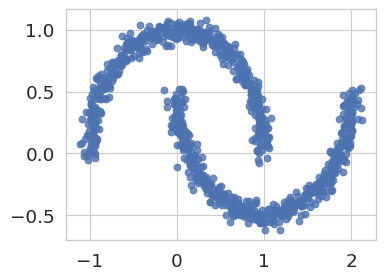

In [ ]:
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.8);

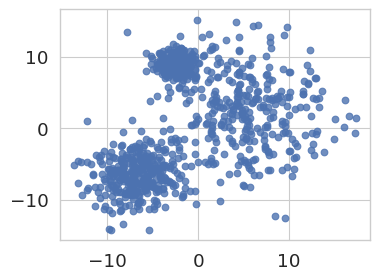

In [ ]:
plt.scatter(X3[:, 0], X3[:, 1], alpha=0.8);